In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import joblib

# Load raw data
df = pd.read_csv("traffic_data.csv")

# Encode protocol ONCE
df["protocol"] = df["protocol"].astype("category").cat.codes

# Save feature list
FEATURE_COLUMNS = ["protocol", "packet_size"]

# Scale packet_size
scaler = StandardScaler()
df["packet_size"] = scaler.fit_transform(df[["packet_size"]])

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save processed data
df.to_csv("processed_data.csv", index=False)

print("✅ Data preprocessing complete")


✅ Data preprocessing complete


In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("processed_data.csv")

df.head()




,source_ip,destination_ip,protocol,packet_size
0,192.168.29.146,239.255.255.250,1,1.388213
1,192.168.29.146,224.0.0.251,1,0.033257
2,192.168.29.146,224.0.0.251,1,0.033257
3,192.168.29.146,224.0.0.251,1,0.033257
4,192.168.29.146,224.0.0.251,1,0.033257


In [3]:
import pandas as pd

df = pd.read_csv("processed_data.csv")

# Drop IPs (not ML features)
df = df.drop(columns=["source_ip", "destination_ip"], errors="ignore")

# Ensure numeric
df = df.apply(pd.to_numeric, errors="coerce").fillna(0)

# Create demo labels
df["attack"] = (df["packet_size"] > df["packet_size"].mean()).astype(int)

df.to_csv("final_numeric_data.csv", index=False)

print("✅ Training data ready")


✅ Training data ready


In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import joblib

FEATURE_COLUMNS = ["protocol", "packet_size"]

df = pd.read_csv("final_numeric_data.csv")

X = df[FEATURE_COLUMNS]
y = df["attack"]

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

joblib.dump(model, "rf_model_v1.pkl")

print("✅ Random Forest model saved")



✅ Random Forest model saved


In [5]:
import torch
import torch.nn as nn
import pandas as pd

FEATURE_COLUMNS = ["protocol", "packet_size"]

df = pd.read_csv("final_numeric_data.csv")
X = torch.tensor(df[FEATURE_COLUMNS].values, dtype=torch.float32)

class AutoEncoder(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.encoder = nn.Linear(input_size, 2)
        self.decoder = nn.Linear(2, input_size)

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = AutoEncoder(X.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

for epoch in range(300):
    optimizer.zero_grad()
    output = model(X)
    loss = loss_fn(output, X)
    loss.backward()
    optimizer.step()

torch.save(model.state_dict(), "autoencoder_v1.pth")

print("✅ Autoencoder saved")


KeyboardInterrupt: 

In [ ]:
# STEP 1: Drop IP address columns
df = df.drop(columns=["source_ip", "destination_ip"], errors="ignore")

# STEP 2: Convert protocol (TCP/UDP) to numbers
df["protocol"] = df["protocol"].astype("category").cat.codes

# STEP 3: Create fake labels (for demo purpose)
# Large packets = suspicious (example logic)
df["attack"] = (df["packet_size"] > df["packet_size"].mean()).astype(int)

In [ ]:

X = df.drop("attack", axis=1)
y = df["attack"]



In [ ]:
X

,protocol,packet_size
0,2,1.388213
1,2,0.033257
2,2,0.033257
3,2,0.033257
4,2,0.033257
...,...,...
1504,0,-0.091815
1505,0,-0.091815
1506,0,-0.091815
1507,2,1.388213


In [ ]:
y

0       1
1       1
2       1
3       1
4       1
       ..
1504    0
1505    0
1506    0
1507    1
1508    1
Name: attack, Length: 1509, dtype: int32

In [ ]:
model = RandomForestClassifier()
model.fit(X, y)

predictions = model.predict(X)
print("Detected attacks:", sum(predictions))

Detected attacks: 334


In [ ]:
import pandas as pd

# Load your data
df = pd.read_csv("processed_data.csv")

print("Before cleaning:")
print(df.head())
print(df.dtypes)

# REMOVE IP ADDRESS COLUMNS (this is the key fix)
df = df.drop(columns=["source_ip", "destination_ip"], errors="ignore")

# Ensure all columns are numeric
df = df.apply(pd.to_numeric, errors="coerce")

# Replace missing values (safety)
df = df.fillna(0)

print("\nAfter cleaning:")
print(df.head())
print(df.dtypes)

# Save cleaned data
df.to_csv("final_numeric_data.csv", index=False)
print("\nSaved final_numeric_data.csv")


Before cleaning:
        source_ip   destination_ip  protocol  packet_size
0  192.168.29.146  239.255.255.250         1     1.388213
1  192.168.29.146      224.0.0.251         1     0.033257
2  192.168.29.146      224.0.0.251         1     0.033257
3  192.168.29.146      224.0.0.251         1     0.033257
4  192.168.29.146      224.0.0.251         1     0.033257
source_ip          object
destination_ip     object
protocol            int64
packet_size       float64
dtype: object

After cleaning:
   protocol  packet_size
0         1     1.388213
1         1     0.033257
2         1     0.033257
3         1     0.033257
4         1     0.033257
protocol         int64
packet_size    float64
dtype: object

Saved final_numeric_data.csv


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib

# Load dataset
df = pd.read_csv("final_numeric_data.csv")
df["attack"] = (df["packet_size"] > df["packet_size"].mean()).astype(int)  # Example label

X = df.drop("attack", axis=1)
y = df["attack"]

# Train or load model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)
# joblib.dump(rf_model, "rf_model_v1.pkl")  # save model if needed

# Predictions
y_pred = rf_model.predict(X)

# Performance metrics
acc = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred)
rec = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
cm = confusion_matrix(y, y_pred)

print("Random Forest Performance:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print("Confusion Matrix:")
print(cm)


Random Forest Performance:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000
Confusion Matrix:
[[1175    0]
 [   0  334]]


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import joblib  # for saving models

# Load numeric dataset
df = pd.read_csv("final_numeric_data.csv")

# Example label
df["attack"] = (df["packet_size"] > df["packet_size"].mean()).astype(int)

X = df.drop("attack", axis=1)
y = df["attack"]

# Train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Save model locally
joblib.dump(rf_model, "rf_model_v1.pkl")
print("Random Forest model saved as rf_model_v1.pkl")


Random Forest model saved as rf_model_v1.pkl


In [ ]:
import torch
import torch.nn as nn
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load numeric data
df = pd.read_csv("final_numeric_data.csv")
X = torch.tensor(df.values, dtype=torch.float32)

# Example true labels
y_true = (df["packet_size"] > df["packet_size"].mean()).astype(int)

# Autoencoder model
class AutoEncoder(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.encoder = nn.Linear(input_size, 2)
        self.decoder = nn.Linear(2, input_size)
    def forward(self, x):
        return self.decoder(self.encoder(x))

model = AutoEncoder(X.shape[1])
# Assume model already trained and loaded
# model.load_state_dict(torch.load("autoencoder_v1.pth"))
model.eval()

# Compute reconstruction error
with torch.no_grad():
    reconstructed = model(X)
    error = ((X - reconstructed) ** 2).mean(dim=1)

threshold = error.mean() + error.std()
y_pred = (error > threshold).int().numpy()

# Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("Autoencoder Performance:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print("Confusion Matrix:")
print(cm)


Autoencoder Performance:
Accuracy: 0.7840
Precision: 1.0000
Recall: 0.0240
F1-score: 0.0468
Confusion Matrix:
[[1175    0]
 [ 326    8]]


In [ ]:
import torch
import torch.nn as nn
import pandas as pd

df = pd.read_csv("final_numeric_data.csv")
data = torch.tensor(df.values, dtype=torch.float32)

class AutoEncoder(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.encoder = nn.Linear(input_size, 2)
        self.decoder = nn.Linear(2, input_size)
    def forward(self, x):
        return self.decoder(self.encoder(x))

autoencoder = AutoEncoder(data.shape[1])

optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

# Train
for epoch in range(300):
    optimizer.zero_grad()
    output = autoencoder(data)
    loss = loss_fn(output, data)
    loss.backward()
    optimizer.step()

# Save PyTorch model
torch.save(autoencoder.state_dict(), "autoencoder_v1.pth")
print("Autoencoder saved as autoencoder_v1.pth")


Autoencoder saved as autoencoder_v1.pth


In [ ]:
import torch
import torch.nn as nn
import pandas as pd

# Load numeric-only data
df = pd.read_csv("final_numeric_data.csv")

data = torch.tensor(df.values, dtype=torch.float32)

class AutoEncoder(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.encoder = nn.Linear(input_size, 2)
        self.decoder = nn.Linear(2, input_size)

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = AutoEncoder(data.shape[1])

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

# Train
for epoch in range(300):
    optimizer.zero_grad()
    output = model(data)
    loss = loss_fn(output, data)
    loss.backward()
    optimizer.step()

# Anomaly detection
reconstruction_error = ((model(data) - data) ** 2).mean(dim=1)
threshold = reconstruction_error.mean() + reconstruction_error.std()

print("Zero-day anomalies detected:",
      (reconstruction_error > threshold).sum().item())


Zero-day anomalies detected: 229


In [ ]:
import hashlib
import time

def log_attack(data):
    hash_value = hashlib.sha256(data.encode()).hexdigest()
    print("BLOCKCHAIN LOG")
    print("Hash:", hash_value)
    print("Time:", time.ctime())

log_attack("Suspicious traffic detected")


c:\Users\user7\anaconda3\envs\myenv\lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
c:\Users\user7\anaconda3\envs\myenv\lib\site-packages\shap\plots\_beeswarm.py:758: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0, w_pad=0, h_pad=0.0)


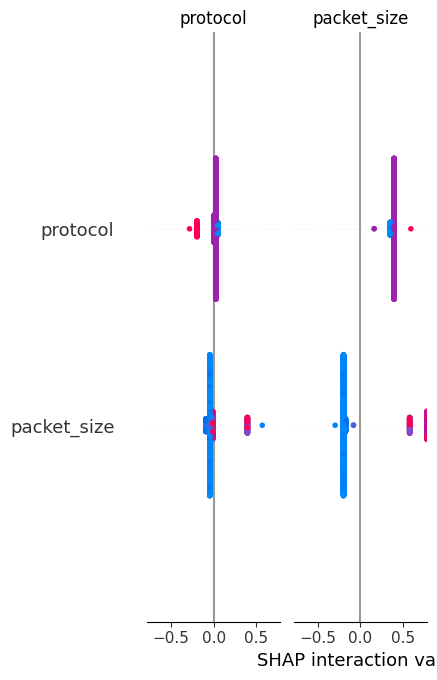

In [ ]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X)

# Summary plot
shap.summary_plot(shap_values, X)


## Report Results and Graphs

These cells generate report-ready metrics and figures for the trained models.
All images are saved into `report_figures/`.


In [6]:
# REPORT_CELL_SETUP_V2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split

sns.set_style('whitegrid')
FIG_DIR = 'report_figures'
os.makedirs(FIG_DIR, exist_ok=True)

df_report = pd.read_csv('final_numeric_data.csv')
if 'attack' not in df_report.columns:
    df_report['attack'] = (df_report['packet_size'] > df_report['packet_size'].mean()).astype(int)

X_report = df_report.drop(columns=['attack'])
y_report = df_report['attack'].astype(int)

stratify_target = y_report if y_report.nunique() > 1 else None
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_report, y_report, test_size=0.20, random_state=42, stratify=stratify_target
)

train_val_stratify = y_train_val if y_train_val.nunique() > 1 else None
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=train_val_stratify
)

rf_report = RandomForestClassifier(n_estimators=200, random_state=42)
rf_report.fit(X_train, y_train)

y_val_pred = rf_report.predict(X_val)
y_val_prob = rf_report.predict_proba(X_val)[:, 1]
y_test_pred = rf_report.predict(X_test)
rf_prob = rf_report.predict_proba(X_test)[:, 1]

rf_comparison_df = pd.DataFrame([
    {
        'Split': 'Validation',
        'Accuracy': accuracy_score(y_val, y_val_pred),
        'Precision': precision_score(y_val, y_val_pred, zero_division=0),
        'Recall': recall_score(y_val, y_val_pred, zero_division=0),
        'F1-score': f1_score(y_val, y_val_pred, zero_division=0),
    },
    {
        'Split': 'Test',
        'Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred, zero_division=0),
        'Recall': recall_score(y_test, y_test_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_test_pred, zero_division=0),
    }
])

print('Random Forest validation vs test metrics:')
print(rf_comparison_df.round(4))


RuntimeError: Only a single TORCH_LIBRARY can be used to register the namespace prims; please put all of your definitions in a single TORCH_LIBRARY block.  If you were trying to specify implementations, consider using TORCH_LIBRARY_IMPL (which can be duplicated).  If you really intended to define operators for a single namespace in a distributed way, you can use TORCH_LIBRARY_FRAGMENT to explicitly indicate this.  Previous registration of TORCH_LIBRARY was registered at /dev/null:488; latest registration was registered at /dev/null:488

In [ ]:
# REPORT_CELL_RF_PLOTS_V2
rf_plot_df = rf_comparison_df.melt(id_vars='Split', var_name='Metric', value_name='Score')

plt.figure(figsize=(8, 5))
sns.barplot(data=rf_plot_df, x='Metric', y='Score', hue='Split', palette=['#f4a261', '#2a9d8f'])
plt.title('Random Forest Validation vs Test Metrics')
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/rf_validation_vs_test_metrics.png', dpi=300)
plt.show()

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Random Forest Test Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/rf_confusion_matrix.png', dpi=300)
plt.show()

val_fpr, val_tpr, _ = roc_curve(y_val, y_val_prob)
val_roc_auc = auc(val_fpr, val_tpr)
fpr, tpr, _ = roc_curve(y_test, rf_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(val_fpr, val_tpr, label=f'Validation AUC = {val_roc_auc:.3f}', color='darkorange')
plt.plot(fpr, tpr, label=f'Test AUC = {roc_auc:.3f}', color='navy')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title('Random Forest ROC Curve: Validation vs Test')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/rf_roc_curve.png', dpi=300)
plt.show()

importance_df = pd.DataFrame({
    'Feature': X_report.columns,
    'Importance': rf_report.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature', dodge=False, palette='viridis', legend=False)
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/rf_feature_importance.png', dpi=300)
plt.show()

print('Saved Random Forest figures to report_figures/:')
print('- rf_validation_vs_test_metrics.png')
print('- rf_confusion_matrix.png')
print('- rf_roc_curve.png')
print('- rf_feature_importance.png')


In [ ]:
%pip install sympy


   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.3 MB ? eta -:--:--
   --- ------------------------------------ 0.5/6.3 MB 524.3 kB/s eta 0:00:12
   --- ------------------------------------ 0.5/6.3 MB 524.3 kB/s eta 0:00:12
   --- ------------------------------------ 0.5/6.3 MB 524.3 kB/s eta 0:00:12
   ---- ----------------------------------- 0.8/6.3 MB 459.5 kB/s eta 0:00:12
   ---- ----------------------------------- 0.8/6.3 MB 459.5 kB/s eta 0:00:12
   ------ --------------------------------- 1.0/6.3 MB 508.4 kB/s eta 0:00:11
   ------ --------------------------------- 1.0/6.3 MB 508.4 kB/s eta 0:00:11
   -------- ------------------------------- 1.3/6.3 MB 516.3 kB/s eta 0:00:10
   -------- -------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.8.0+cpu requires filelock, which is not installed.
torch 2.8.0+cpu requires fsspec, which is not installed.
torch 2.8.0+cpu requires jinja2, which is not installed.
torch 2.8.0+cpu requires networkx, which is not installed.


Autoencoder metrics:
         Model  Accuracy  Precision  Recall  F1-score
0  Autoencoder     0.784        1.0   0.024    0.0468


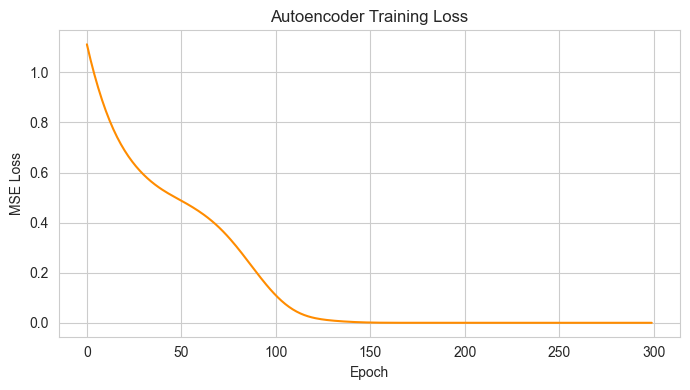

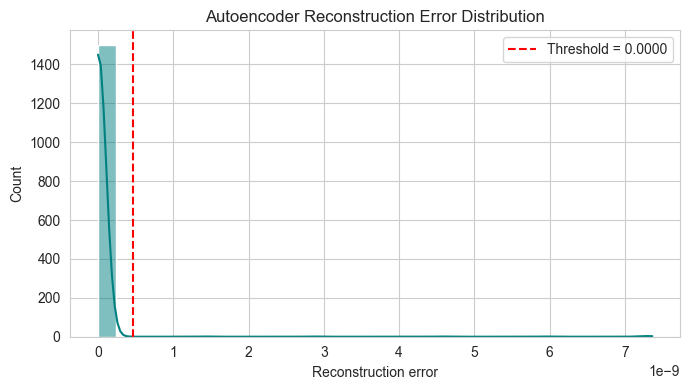

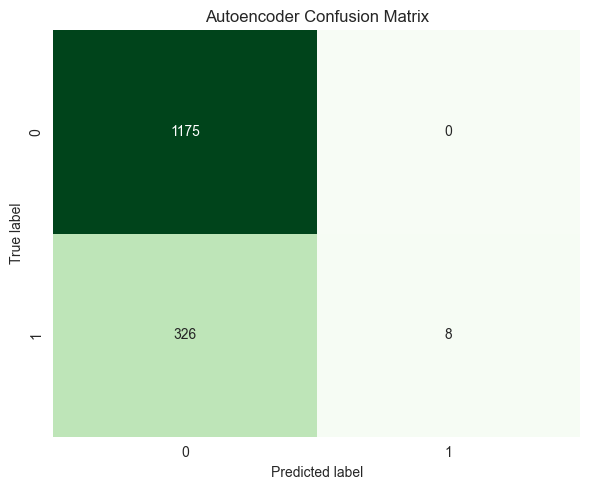

<Figure size 800x400 with 0 Axes>

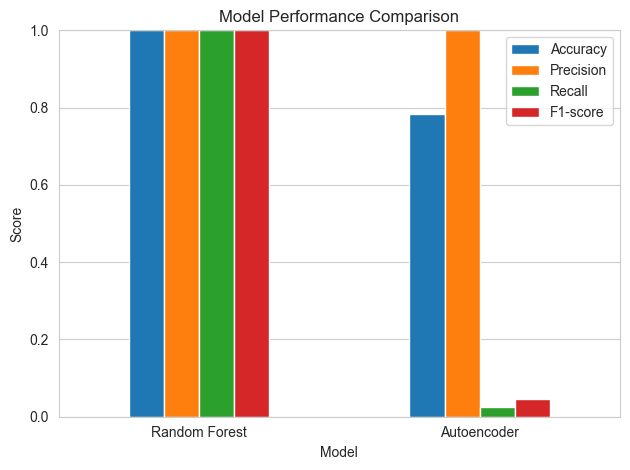

Saved Autoencoder and comparison figures to report_figures/:
- autoencoder_training_loss.png
- autoencoder_error_distribution.png
- autoencoder_confusion_matrix.png
- model_performance_comparison.png


In [ ]:
# REPORT_CELL_AUTOENCODER_V1
class AutoEncoder(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.encoder = nn.Linear(input_size, 2)
        self.decoder = nn.Linear(2, input_size)

    def forward(self, x):
        return self.decoder(self.encoder(x))

X_tensor = torch.tensor(X_report.values, dtype=torch.float32)
ae_model = AutoEncoder(X_tensor.shape[1])
optimizer = torch.optim.Adam(ae_model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

loss_history = []
for epoch in range(300):
    optimizer.zero_grad()
    recon = ae_model(X_tensor)
    loss = loss_fn(recon, X_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

with torch.no_grad():
    reconstruction_error = ((ae_model(X_tensor) - X_tensor) ** 2).mean(dim=1).numpy()

threshold = reconstruction_error.mean() + reconstruction_error.std()
y_pred_ae = (reconstruction_error > threshold).astype(int)

ae_metrics = {
    'Model': 'Autoencoder',
    'Accuracy': accuracy_score(y_report, y_pred_ae),
    'Precision': precision_score(y_report, y_pred_ae, zero_division=0),
    'Recall': recall_score(y_report, y_pred_ae, zero_division=0),
    'F1-score': f1_score(y_report, y_pred_ae, zero_division=0),
}

print('Autoencoder metrics:')
print(pd.DataFrame([ae_metrics]).round(4))

plt.figure(figsize=(7, 4))
plt.plot(loss_history, color='darkorange')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/autoencoder_training_loss.png', dpi=300)
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(reconstruction_error, bins=30, kde=True, color='teal')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.4f}')
plt.title('Autoencoder Reconstruction Error Distribution')
plt.xlabel('Reconstruction error')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/autoencoder_error_distribution.png', dpi=300)
plt.show()

ae_cm = confusion_matrix(y_report, y_pred_ae)
plt.figure(figsize=(6, 5))
sns.heatmap(ae_cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Autoencoder Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/autoencoder_confusion_matrix.png', dpi=300)
plt.show()

model_compare_df = pd.DataFrame([rf_metrics, ae_metrics]).set_index('Model')
plt.figure(figsize=(8, 4))
model_compare_df.plot(kind='bar', ylim=(0, 1), rot=0)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/model_performance_comparison.png', dpi=300)
plt.show()

print('Saved Autoencoder and comparison figures to report_figures/:')
print('- autoencoder_training_loss.png')
print('- autoencoder_error_distribution.png')
print('- autoencoder_confusion_matrix.png')
print('- model_performance_comparison.png')
